# Deutschlandticket Commute Analysis

**Destination:** Johnson & Johnson Medical GmbH, Robert-Koch-Strasse 1, 22851 Norderstedt.

**Question:** How attractive would public transport, and specifically the Deutschlandticket, be for employees commuting to this site?

## Approach
1. Generate a synthetic workforce living around Hamburg. No real employee data is used.
2. Assess the transit connection for each home. Compute a real door-to-door commute using a live HVV routing service, with a distance-based fallback if a call fails.
3. Group commutes into time bands.
4. Score each employee for Deutschlandticket adoption using a transparent weighted model.
5. Summarise the findings and draw an interactive map.

## Note on the adoption score
There is no real adoption ground truth to train on. The score is a stated, interpretable model, not a learned one. Every weight and cost assumption lives in `src/config.py` so it can be inspected and changed. The Deutschlandticket price used is 63 EUR per month, the rate from January 2026.

In [41]:
import os, sys
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src import config, synthetic, routing, scoring, mapping

os.makedirs("outputs", exist_ok=True)
pd.set_option("display.width", 120)

WORKPLACE = config.WORKPLACE
WORKPLACE

{'name': 'Johnson & Johnson Medical GmbH',
 'address': 'Robert-Koch-Strasse 1, 22851 Norderstedt',
 'lat': 53.686952,
 'lon': 10.046418}

In [42]:
# Check the routing service before the full run, and handle it gracefully.
import requests

def api_available(base=config.API_BASE, timeout=15):
    try:
        r = requests.get(f"{base}/locations",
                         params={"query": "Norderstedt", "results": 1},
                         timeout=timeout)
        r.raise_for_status()
        return bool(r.json())
    except requests.exceptions.HTTPError as e:
        print(f"Routing service returned an HTTP error: {e.response.status_code}. "
              "Falling back to the built-in estimator.")
    except requests.exceptions.Timeout:
        print("Routing service timed out. Falling back to the built-in estimator.")
    except requests.exceptions.RequestException as e:
        print(f"Could not reach the routing service ({e}). "
              "Falling back to the built-in estimator.")
    return False

USE_API = api_available()
print("USE_API =", USE_API)

Routing service returned an HTTP error: 503. Falling back to the built-in estimator.
USE_API = False


## 1. Synthetic data generation
Homes are sampled around residential centres in Hamburg and the surrounding towns, weighted to look like a realistic population spread. Each home is offset randomly from its centre. Car ownership rises with distance from the city core.

In [43]:
N = 200  # number of synthetic employees

employees = synthetic.generate_employees(n=N, seed=config.RANDOM_SEED)
print(employees.shape)
employees.head()

(200, 6)


,employee_id,area,home_lat,home_lon,age,owns_car
0,E1000,Wedel,53.591694,9.699043,35,1
1,E1001,Wandsbek,53.581898,10.084559,50,1
2,E1002,Reinbek,53.519562,10.280895,44,0
3,E1003,Ahrensburg,53.675469,10.258577,21,1
4,E1004,Hamburg-Mitte,53.504125,9.991858,47,0


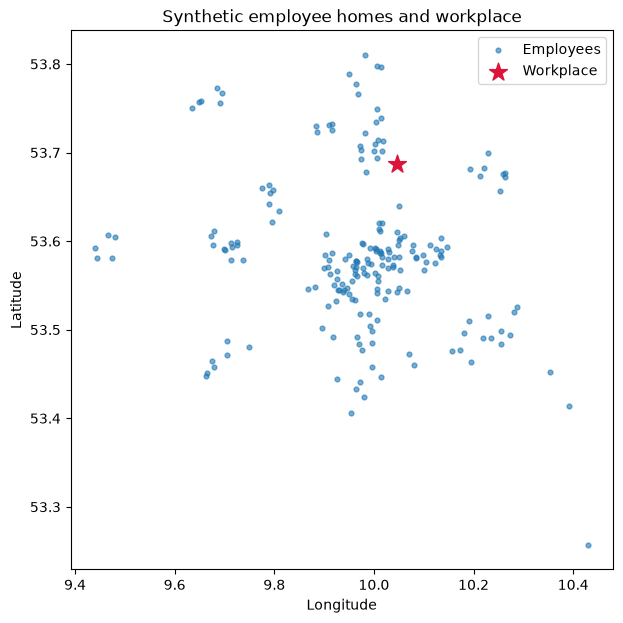

In [44]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(employees["home_lon"], employees["home_lat"], s=12, alpha=0.6, label="Employees")
ax.scatter(WORKPLACE["lon"], WORKPLACE["lat"], s=180, marker="*", color="crimson", label="Workplace")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Synthetic employee homes and workplace")
ax.legend(); plt.show()

## 2. Public transport connection assessment
The workplace is geocoded live. The nearest HVV stations to the site are pulled from the routing service. These give a first read on how well the destination itself is connected.

In [ ]:
wp_lat, wp_lon = routing.geocode(WORKPLACE["address"], fallback=(WORKPLACE["lat"], WORKPLACE["lon"]))
print("Workplace coordinates:", round(wp_lat, 6), round(wp_lon, 6))

work_stations = routing.nearby_stops(wp_lat, wp_lon, results=6, distance_m=3000)
pd.DataFrame(work_stations)

## 3. Door-to-door commute time
For each employee a journey is requested that arrives at the site on a weekday morning. The result records total door-to-door minutes, number of transfers, and the walk to the first stop. `USE_API` uses the live service; set it to `False` for an offline dry run. Results are cached, so a rerun is fast.

In [ ]:
USE_API = True  # set False for an offline estimate-only dry run


arrival = routing.next_arrival_iso()
print("Arrival target:", arrival)

records = []
for _, r in tqdm(employees.iterrows(), total=len(employees), desc="Routing"):
    records.append(
        routing.get_commute(r["home_lat"], r["home_lon"], wp_lat, wp_lon,
                            arrival_iso=arrival, use_api=USE_API)
    )
routing.save_cache()

commute_df = pd.DataFrame(records).rename(columns={"duration_min": "commute_min"})
employees = pd.concat([employees.reset_index(drop=True), commute_df], axis=1)

print("Source of commute values:")
print(employees["source"].value_counts())
employees[["area", "commute_min", "n_transfers", "access_walk_min", "source"]].head()

Arrival target: 2026-07-27T08:30:00+02:00


Routing:   0%|          | 0/200 [00:00<?, ?it/s]

Source of commute values:
source
estimate    200
Name: count, dtype: int64


,area,commute_min,n_transfers,access_walk_min,source
0,Wedel,106.0,3,6.0,estimate
1,Wandsbek,54.8,1,6.0,estimate
2,Reinbek,102.7,3,6.0,estimate
3,Ahrensburg,65.6,2,6.0,estimate
4,Hamburg-Mitte,91.1,3,6.0,estimate


## 4. Commute-time grouping
Commutes are placed into bands of 0-30, 30-45, 45-60 and over 60 minutes.

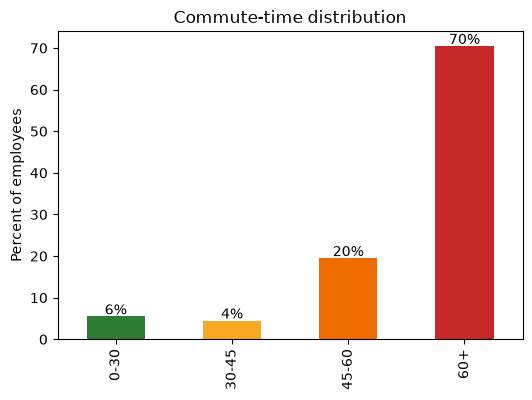

{'per_bin_pct': {'0-30': 5.5, '30-45': 4.5, '45-60': 19.5, '60+': 70.5},
 'within_30_pct': np.float64(5.5),
 'within_45_pct': np.float64(10.0),
 'within_60_pct': np.float64(29.5),
 'over_60_pct': np.float64(70.5)}

In [ ]:
employees["driving_cost_eur"] = employees.apply(
    lambda r: scoring.monthly_driving_cost(r["home_lat"], r["home_lon"], wp_lat, wp_lon), axis=1
).round(1)
employees["savings_eur"] = (employees["driving_cost_eur"] - config.DTICKET_PRICE_EUR).round(1)
employees["commute_bin"] = employees["commute_min"].apply(scoring.bin_commute)

bins = scoring.bin_summary(employees)
bin_pct = pd.Series(bins["per_bin_pct"]).reindex(config.BIN_LABELS)
ax = bin_pct.plot(kind="bar", color=["#2e7d32", "#f9a825", "#ef6c00", "#c62828"], figsize=(6,4))
ax.set_ylabel("Percent of employees"); ax.set_title("Commute-time distribution")
for i, v in enumerate(bin_pct):
    ax.text(i, v + 0.5, f"{v:.0f}%", ha="center")
plt.show()
bins

## 5. Deutschlandticket adoption scoring
The score combines commute time, transfers, walk to the first stop, car ownership and the money saved against driving. It is passed through a logistic function to give a value between 0 and 1, then labelled High, Medium or Low.

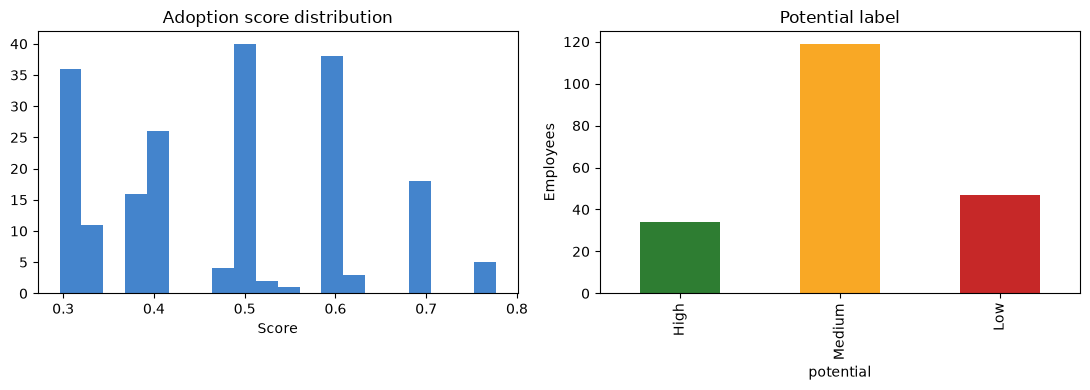

potential
High       34
Medium    119
Low        47
Name: count, dtype: int64

In [ ]:
employees["adoption_score"] = employees.apply(
    lambda r: scoring.adoption_score(r["commute_min"], r["n_transfers"],
                                     r["access_walk_min"], r["owns_car"], r["savings_eur"]),
    axis=1
).round(3)
employees["potential"] = employees["adoption_score"].apply(scoring.potential_label)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(employees["adoption_score"], bins=20, color="#1565c0", alpha=0.8)
ax[0].set_title("Adoption score distribution"); ax[0].set_xlabel("Score")
counts = employees["potential"].value_counts().reindex(["High", "Medium", "Low"])
counts.plot(kind="bar", color=["#2e7d32", "#f9a825", "#c62828"], ax=ax[1])
ax[1].set_title("Potential label"); ax[1].set_ylabel("Employees")
plt.tight_layout(); plt.show()
counts

## 6. Summary findings
The required outputs: share of employees in each time band, adoption potential, strongest and weakest areas, and the factors that drive adoption.

In [ ]:
areas = scoring.area_summary(employees)
factors = scoring.key_factors(employees)
adoption_potential = round(employees["adoption_score"].mean() * 100, 1)

strong = areas.head(5)
weak = areas.tail(5)

lines = []
lines.append(f"# Deutschlandticket Commute Analysis - Summary\n")
lines.append(f"Workplace: {WORKPLACE['name']}, {WORKPLACE['address']}")
lines.append(f"Synthetic employees: {len(employees)}")
lines.append(f"Commute source: {employees['source'].value_counts().to_dict()}\n")

lines.append("## Commute-time distribution")
lines.append(f"- Within 30 minutes: {bins['within_30_pct']}%")
lines.append(f"- Within 45 minutes: {bins['within_45_pct']}%")
lines.append(f"- Within 60 minutes: {bins['within_60_pct']}%")
lines.append(f"- Over 60 minutes: {bins['over_60_pct']}%\n")

lines.append("## Deutschlandticket adoption potential")
lines.append(f"- Mean adoption score: {adoption_potential}%")
hi = (employees['potential'] == 'High').mean() * 100
me = (employees['potential'] == 'Medium').mean() * 100
lo = (employees['potential'] == 'Low').mean() * 100
lines.append(f"- High potential: {hi:.0f}%  Medium: {me:.0f}%  Low: {lo:.0f}%\n")

lines.append("## Areas with strong public transport connectivity")
for a, row in strong.iterrows():
    lines.append(f"- {a}: {row['mean_commute_min']:.0f} min mean, adoption {row['mean_adoption']:.2f}")
lines.append("")
lines.append("## Areas where public transport is less attractive")
for a, row in weak.iterrows():
    lines.append(f"- {a}: {row['mean_commute_min']:.0f} min mean, adoption {row['mean_adoption']:.2f}")
lines.append("")

lines.append("## Key factors influencing adoption")
lines.append("Correlation of each driver with the adoption score:")
for name, val in factors.items():
    lines.append(f"- {name}: {val}")

summary_text = "\n".join(lines)
with open("outputs/summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)
employees.to_csv("outputs/employees.csv", index=False)
print(summary_text)

# Deutschlandticket Commute Analysis - Summary

Workplace: Johnson & Johnson Medical GmbH, Robert-Koch-Strasse 1, 22851 Norderstedt
Synthetic employees: 200
Commute source: {'estimate': 200}

## Commute-time distribution
- Within 30 minutes: 5.5%
- Within 45 minutes: 10.0%
- Within 60 minutes: 29.5%
- Over 60 minutes: 70.5%

## Deutschlandticket adoption potential
- Mean adoption score: 47.8%
- High potential: 17%  Medium: 60%  Low: 24%

## Areas with strong public transport connectivity
- Norderstedt: 29 min mean, adoption 0.64
- Quickborn: 51 min mean, adoption 0.50
- Winterhude: 53 min mean, adoption 0.54
- Barmbek: 55 min mean, adoption 0.60
- Wandsbek: 56 min mean, adoption 0.55

## Areas where public transport is less attractive
- Elmshorn: 109 min mean, adoption 0.34
- Buxtehude: 134 min mean, adoption 0.38
- Geesthacht: 139 min mean, adoption 0.33
- Stade: 154 min mean, adoption 0.38
- Lueneburg: 200 min mean, adoption 0.37

## Key factors influencing adoption
Correlation of ea

## 7. Interactive map
Employees are coloured by commute band. Nearby HVV stations and the workplace are marked. High-potential users are clustered and highlighted. Use the layer control to toggle groups.

In [ ]:
m = mapping.build_map(employees, {**WORKPLACE, "lat": wp_lat, "lon": wp_lon}, work_stations)
m.save("outputs/commute_map.html")
m

## Conclusion and caveats
The pipeline turns a synthetic workforce into a clear read on Deutschlandticket attractiveness: who is close by transit, where connectivity is strong, and where it is weak.

Points to keep in mind:
- The workforce is synthetic. Real home locations would shift the numbers.
- The adoption score is a transparent assumption model, not trained on real behaviour. The weights in `src/config.py` set the result and can be tuned.
- Commute values use real routing where the service responds and an estimate otherwise. The `source` column shows which was used for each row.
- Savings can correlate with distance, so far employees who save the most on driving also face the longest trips. The model balances both.